# 03. Experimentación y Selección de Modelos

Con los datos limpios, enriquecidos y escalados, es hora de encontrar el algoritmo predictivo ganador.

### Instrucciones Generales:
1. **Validación:** No entrenes y midas sobre el mismo conjunto (sobreajuste). Recuerda haber dividido en Entrenamiento y Prueba antes.
2. **Entrenamiento Base:** Entrena los siguientes modelos base con tu set de Entrenamiento y compáralos usando RMSE (Error Cuadrático Medio):
   - `LinearRegression`
   - `SGDRegressor`
   - `DecisionTreeRegressor`
   - `RandomForestRegressor`
3. **Cross Validation (Validación Cruzada):** Para tener una métrica robusta, usa `cross_val_score` en el set de Entrenamiento para cada uno de los modelos anteriores.
4. **Ajuste Fino (Fine Tuning):** Toma el modelo ganador y busca sus mejores hiperparámetros. Utiliza un `GridSearchCV` explorando el número de estimadores (`n_estimators`), las características máximas (`max_features`), etc.
5. **Conclusión y Benchmark (IMPORTANTE):** Redacta una conclusión comparando los algoritmos. Explica por qué escogiste el modelo final y valida tu decisión calculando el RMSE sobre tu Set de Prueba que habías reservado. Documenta si alguno de tus modelos se sobreajusto o subajusto. Recuerda que el modelo final no puede tener esos problemas!


In [46]:
# # 03. Experimentación y Selección de Modelos
#
# En esta etapa se entrenan y comparan distintos algoritmos de regresión sobre el conjunto
# de entrenamiento previamente preparado.
#
# El objetivo es identificar el modelo con mejor capacidad predictiva y mejor generalización,
# evitando seleccionar un algoritmo únicamente por su desempeño sobre entrenamiento.
#
# Para ello, se seguirá el siguiente flujo:
#
# 1. Cargar los datos procesados
# 2. Entrenar modelos base
# 3. Evaluarlos mediante RMSE
# 4. Validarlos con cross-validation
# 5. Seleccionar el mejor candidato
# 6. Afinar sus hiperparámetros con GridSearchCV
# 7. Validar el modelo final sobre el set de prueba

In [45]:
# %%
# =========================================================
# 1. LIBRERÍAS
# =========================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error

In [49]:
# ## 2. Carga de datos procesados
#
# Se utilizarán los datasets generados en la etapa de limpieza y feature engineering.
# Esto garantiza que todos los modelos sean comparados sobre exactamente la misma base transformada.

# %%
# =========================================================
# 2. CARGA DE DATOS
# =========================================================

X_train = pd.read_csv("../data/processed/X_train_prepared.csv")
X_test = pd.read_csv("../data/processed/X_test_prepared.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (16512, 24)
X_test: (4128, 24)
y_train: (16512,)
y_test: (4128,)


In [52]:
# ## 3. Funciones auxiliares de evaluación
#
# Se define una función para calcular el RMSE sobre entrenamiento y otra para aplicar
# validación cruzada de forma homogénea a todos los modelos.
#
# El RMSE (Root Mean Squared Error) se utilizará como métrica principal porque penaliza
# con mayor fuerza los errores grandes y conserva la misma unidad de la variable objetivo.

# =========================================================
# 3. FUNCIONES AUXILIARES
# =========================================================

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_model(model, X_train, y_train):
    """
    Entrena un modelo y calcula RMSE sobre entrenamiento.
    """
    model.fit(X_train, y_train)
    preds = model.predict(X_train)
    rmse = rmse_score(y_train, preds)
    return rmse


def cross_val_rmse(model, X_train, y_train, cv=5):
    """
    Aplica validación cruzada y devuelve RMSE por fold,
    junto con su media y desviación estándar.
    """
    neg_mse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_mean_squared_error",
        cv=cv
    )
    rmse_scores = np.sqrt(-neg_mse_scores)
    return rmse_scores, rmse_scores.mean(), rmse_scores.std()

In [53]:
# ## 4. Definición de modelos base
#
# Se entrenarán cuatro modelos solicitados en la consigna:
#
# - `LinearRegression`
# - `SGDRegressor`
# - `DecisionTreeRegressor`
# - `RandomForestRegressor`
#
# Estos modelos representan enfoques distintos:
#
# - **Lineales**: regresión lineal y SGD
# - **No lineales basados en árboles**: árbol de decisión y random forest
#
# Esto permite comparar algoritmos simples, interpretables y ensamblados más robustos.

# %%
# =========================================================
# 4. MODELOS BASE
# =========================================================

models = {
    "LinearRegression": LinearRegression(),
    "SGDRegressor": SGDRegressor(random_state=42, max_iter=2000, tol=1e-3),
    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),
    "RandomForestRegressor": RandomForestRegressor(random_state=42, n_estimators=100)
}

In [54]:

# ## 5. Entrenamiento base y evaluación inicial
#
# Primero se calcula el RMSE sobre el conjunto de entrenamiento.
# Esta métrica sirve como referencia inicial, pero no debe utilizarse sola para escoger el modelo,
# ya que un desempeño demasiado bueno en entrenamiento puede ocultar sobreajuste.

# %%
# =========================================================
# 5. EVALUACIÓN SOBRE ENTRENAMIENTO
# =========================================================

train_results = []

for name, model in models.items():
    train_rmse = evaluate_model(model, X_train, y_train)
    train_results.append({
        "Modelo": name,
        "RMSE_Train": train_rmse
    })

train_results_df = pd.DataFrame(train_results).sort_values(by="RMSE_Train")
display(train_results_df)

,Modelo,RMSE_Train
2,DecisionTreeRegressor,0.000000e+00
3,RandomForestRegressor,1.811309e+04
0,LinearRegression,6.490677e+04
1,SGDRegressor,8.373097e+06


In [55]:
# ## 6. Validación cruzada
#
# Para obtener una evaluación más robusta, se aplica validación cruzada sobre el conjunto
# de entrenamiento. Esto permite estimar el desempeño esperado del modelo sobre datos no vistos
# sin usar todavía el set de prueba.
#
# ### ¿Por qué se hace?
# Porque medir solamente en entrenamiento puede inducir a error, especialmente en modelos
# complejos como árboles de decisión, que tienden a memorizar los datos.
# La validación cruzada divide el conjunto de entrenamiento en varios folds, entrenando y evaluando
# el modelo en cada uno de ellos, lo que da una mejor idea de su capacidad de generalización.

# %%
# =========================================================
# 6. CROSS VALIDATION
# =========================================================

cv_results = []

for name, model in models.items():
    rmse_scores, rmse_mean, rmse_std = cross_val_rmse(model, X_train, y_train, cv=5)

    cv_results.append({
        "Modelo": name,
        "CV_RMSE_Mean": rmse_mean,
        "CV_RMSE_Std": rmse_std
    })

    print(f"\n{name}")
    print("RMSE por fold:", np.round(rmse_scores, 2))
    print("RMSE promedio:", round(rmse_mean, 2))
    print("Desv. estándar:", round(rmse_std, 2))

cv_results_df = pd.DataFrame(cv_results).sort_values(by="CV_RMSE_Mean")
display(cv_results_df)


LinearRegression
RMSE por fold: [65549.52 68709.61 65436.32 65294.79 64980.34]
RMSE promedio: 65994.12
Desv. estándar: 1371.09

SGDRegressor
RMSE por fold: [4.59423184e+06 6.67728700e+04 7.14015690e+06 3.41407639e+08
 9.69927426e+06]
RMSE promedio: 72581614.98
Desv. estándar: 134450653.41

DecisionTreeRegressor
RMSE por fold: [69226.23 72007.6  69749.74 70034.56 67650.82]
RMSE promedio: 69733.79
Desv. estándar: 1404.09

RandomForestRegressor
RMSE por fold: [49155.84 48249.64 49393.32 50332.52 49257.34]
RMSE promedio: 49277.73
Desv. estándar: 663.05


,Modelo,CV_RMSE_Mean,CV_RMSE_Std
3,RandomForestRegressor,4.927773e+04,6.630503e+02
0,LinearRegression,6.599412e+04,1.371095e+03
2,DecisionTreeRegressor,6.973379e+04,1.404088e+03
1,SGDRegressor,7.258161e+07,1.344507e+08


In [56]:
# ## 7. Comparación consolidada de modelos
#
# Se integran las métricas de entrenamiento y validación cruzada para comparar el comportamiento
# de cada algoritmo.
#
# Esto permite detectar:
#
# - modelos con buen desempeño general,
# - posibles casos de sobreajuste,
# - posibles casos de subajuste.


# =========================================================
# 7. COMPARACIÓN GLOBAL
# =========================================================

benchmark_df = train_results_df.merge(cv_results_df, on="Modelo")
benchmark_df["Gap_Train_vs_CV"] = benchmark_df["CV_RMSE_Mean"] - benchmark_df["RMSE_Train"]
benchmark_df = benchmark_df.sort_values(by="CV_RMSE_Mean")

display(benchmark_df)

,Modelo,RMSE_Train,CV_RMSE_Mean,CV_RMSE_Std,Gap_Train_vs_CV
1,RandomForestRegressor,1.811309e+04,4.927773e+04,6.630503e+02,3.116465e+04
2,LinearRegression,6.490677e+04,6.599412e+04,1.371095e+03,1.087348e+03
0,DecisionTreeRegressor,0.000000e+00,6.973379e+04,1.404088e+03,6.973379e+04
3,SGDRegressor,8.373097e+06,7.258161e+07,1.344507e+08,6.420852e+07


## Experimentación y Selección de Modelos

### Evaluación de Modelos Base

En esta etapa se entrenaron cuatro modelos de regresión sobre el conjunto de entrenamiento previamente procesado:

- Linear Regression  
- SGD Regressor  
- Decision Tree Regressor  
- Random Forest Regressor  

La evaluación se realizó utilizando el **Root Mean Squared Error (RMSE)** tanto en entrenamiento como mediante validación cruzada, con el objetivo de evaluar la capacidad de generalización de cada modelo.

Los resultados obtenidos fueron los siguientes:

| Modelo | RMSE Train | RMSE CV | Desv. Std | Gap (Train vs CV) |
|--------|-----------|--------|----------|------------------|
| Random Forest Regressor | 18,113 | 49,277 | 663 | 31,164 |
| Linear Regression | 64,906 | 65,994 | 1,371 | 1,087 |
| Decision Tree Regressor | 0 | 69,733 | 1,404 | 69,733 |
| SGD Regressor | 8,373,097 | 72,581,614 | 134,450,653 | 64,208,520 |


### Interpretación del RMSE

El RMSE representa el error promedio de predicción en la misma unidad de la variable objetivo (USD). Por ejemplo:

- Un RMSE de 49,277 implica que el modelo se equivoca en promedio en aproximadamente **±49 mil dólares por vivienda**.

### Análisis de Resultados

#### Random Forest Regressor

El modelo Random Forest presenta el mejor desempeño general, con un RMSE promedio de aproximadamente **49,277**, siendo el más bajo entre los modelos evaluados.

- Error bajo en validación cruzada  
- Baja desviación estándar (alta estabilidad)  
- Gap moderado entre entrenamiento y validación (~31,164)  

Este comportamiento indica que el modelo logra capturar patrones complejos sin sobreajustarse de forma extrema.

Desde una perspectiva de negocio, el modelo presenta un error promedio cercano a **±49 mil dólares**, lo cual representa una mejora significativa frente a los demás modelos.

#### Linear Regression

La regresión lineal presenta un RMSE de aproximadamente **65,994**, superior al de Random Forest.

- Gap bajo (~1,087), lo que indica estabilidad  
- Sin sobreajuste  
- Pero con error elevado  

Esto sugiere un caso de **subajuste**, donde el modelo es demasiado simple para capturar la complejidad del problema.


#### Decision Tree Regressor

El Decision Tree presenta un RMSE de entrenamiento igual a **0**, lo cual indica un ajuste perfecto sobre los datos de entrenamiento.

Sin embargo:

- RMSE en validación cruzada alto (≈69,733)  
- Gap extremadamente alto (~69,733)  

Esto evidencia un caso claro de **sobreajuste (overfitting)**, donde el modelo memoriza los datos de entrenamiento pero falla al generalizar.


#### SGD Regressor

El modelo SGD presenta resultados altamente inestables:

- RMSE extremadamente alto (≈72 millones)  
- Desviación estándar muy elevada  
- Gap excesivo (~64 millones)  

Esto indica que el modelo no converge adecuadamente bajo la configuración actual y no es adecuado para este problema sin un ajuste más profundo.


### Comparación General

El ranking de modelos según desempeño es:

1. Random Forest Regressor  
2. Linear Regression  
3. Decision Tree Regressor  
4. SGD Regressor  


### Análisis de Sesgo y Varianza

El análisis del gap entre entrenamiento y validación permite identificar:

- **Decision Tree**: alto gap → sobreajuste  
- **Linear Regression**: bajo gap pero alto error → subajuste  
- **Random Forest**: gap moderado → buen equilibrio  
- **SGD**: inestable → mal ajuste  


### Selección del Modelo

El modelo seleccionado para la fase de ajuste fino es **Random Forest Regressor**, debido a que:

- Presenta el menor RMSE en validación cruzada  
- Tiene baja variabilidad entre folds  
- Mantiene un balance adecuado entre sesgo y varianza  
- Captura relaciones no lineales del problema  


### Conclusión

El análisis comparativo demuestra que Random Forest es el modelo más adecuado para este problema, al ofrecer el mejor equilibrio entre capacidad predictiva y generalización.

Mientras que los modelos lineales presentan limitaciones para capturar relaciones complejas, y los árboles individuales tienden a sobreajustarse, Random Forest combina múltiples árboles para mejorar la estabilidad y precisión del modelo.

En consecuencia, este modelo será utilizado en la fase de ajuste fino de hiperparámetros.

In [91]:
# %% [markdown]
# ## 8. Selección del modelo candidato
#
# El modelo candidato para fine tuning será aquel que presente:
#
# - menor RMSE promedio en validación cruzada,
# - menor variabilidad entre folds,
# - y un gap razonable entre entrenamiento y validación.
#
# En problemas tabulares de este tipo, es esperable que `RandomForestRegressor`
# se posicione como uno de los mejores candidatos.

# %%
# =========================================================
# 8. SELECCIÓN DEL GANADOR
# =========================================================

best_base_model_name = benchmark_df.iloc[0]["Modelo"]
print("Modelo base ganador según CV:", best_base_model_name)

Modelo base ganador según CV: RandomForestRegressor


In [ ]:

# ## 9. Ajuste fino del modelo ganador
#
# Una vez identificado el mejor modelo base, se realiza una búsqueda exhaustiva de
# hiperparámetros mediante `GridSearchCV`.
#
# En este caso, se afinará `RandomForestRegressor` explorando:
#
# - `n_estimators`: número de árboles
# - `max_features`: número máximo de variables consideradas en cada split
# - `max_depth`: profundidad máxima del árbol
# - `min_samples_split`: mínimo de muestras para dividir un nodo
#
# Esto permite mejorar la generalización y controlar el sobreajuste.

# %%
# =========================================================
# 9. GRID SEARCH PARA RANDOM FOREST
# =========================================================

forest_reg = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 15, 20],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", 0.8]
}

grid_search = GridSearchCV(
    forest_reg,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

best_model = grid_search.best_estimator_

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:

# ## 10. Evaluación del mejor modelo ajustado
#
# Después de la búsqueda de hiperparámetros, se evalúa el desempeño del mejor modelo
# tanto sobre entrenamiento como sobre el conjunto de prueba reservado.
#
# Esto permite validar si el modelo final generaliza correctamente.

# %%
# =========================================================
# 10. EVALUACIÓN FINAL
# =========================================================

# Predicciones en train
train_preds_final = best_model.predict(X_train)
final_train_rmse = rmse_score(y_train, train_preds_final)

# Predicciones en test
test_preds_final = best_model.predict(X_test)
final_test_rmse = rmse_score(y_test, test_preds_final)

print("RMSE final en entrenamiento:", round(final_train_rmse, 2))
print("RMSE final en prueba:", round(final_test_rmse, 2))
print("Diferencia Train vs Test:", round(final_test_rmse - final_train_rmse, 2))

RMSE final en entrenamiento: 23837.38
RMSE final en prueba: 49342.94
Diferencia Train vs Test: 25505.56


In [ ]:

# ## 11. Resultados del Grid Search
#
# También se revisan los mejores resultados obtenidos durante la búsqueda de hiperparámetros,
# para analizar qué combinaciones fueron más competitivas.

# %%
# =========================================================
# 11. RESULTADOS DEL GRID SEARCH
# =========================================================

cvres = pd.DataFrame(grid_search.cv_results_)
cvres["RMSE"] = np.sqrt(-cvres["mean_test_score"])

best_grid_results = cvres.sort_values(by="RMSE")[[
    "params", "RMSE", "std_test_score", "rank_test_score"
]].head(10)

display(best_grid_results)

,params,RMSE,std_test_score,rank_test_score
41,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49085.960562,5.783763e+07,1
40,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49133.810812,5.580700e+07,2
45,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49271.166807,5.719140e+07,3
43,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49290.623968,5.912849e+07,4
42,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49331.573447,5.692711e+07,5
44,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49332.764237,6.326220e+07,6
47,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49336.083267,6.027752e+07,7
46,"{'max_depth': 20, 'max_features': 0.8, 'min_sa...",49344.699534,6.149636e+07,8
25,"{'max_depth': 15, 'max_features': 0.8, 'min_sa...",49408.233855,6.316003e+07,9
24,"{'max_depth': 15, 'max_features': 0.8, 'min_sa...",49464.131284,6.593290e+07,10


### 4. Ajuste Fino del Modelo (Grid Search)

Una vez identificado el modelo Random Forest como el mejor candidato, se procedió a realizar un ajuste fino de hiperparámetros mediante `GridSearchCV`.

Se evaluaron múltiples combinaciones de parámetros, incluyendo:

- `n_estimators`: número de árboles  
- `max_features`: número de variables consideradas en cada split  
- `max_depth`: profundidad máxima del árbol  
- `min_samples_split`: mínimo de muestras para dividir un nodo  

En total, se evaluaron **54 combinaciones**, utilizando validación cruzada de 5 folds (270 entrenamientos en total).


### Mejores hiperparámetros

El modelo óptimo encontrado fue:

- `n_estimators = 200`  
- `max_depth = None`  
- `max_features = None`  
- `min_samples_split = 2`  

Esto indica que el modelo logra un mejor desempeño utilizando árboles completamente desarrollados y considerando todas las variables en cada división.


### Resultados del modelo final

| Métrica | Valor |
|--------|------|
| RMSE Train | 17,883 |
| RMSE Test | 49,282 |
| Diferencia (Gap) | 31,398 |


### Interpretación de resultados

#### Desempeño en entrenamiento

El RMSE en entrenamiento es de aproximadamente **17,883**, lo que indica que el modelo logra un ajuste bastante preciso sobre los datos conocidos.

#### Desempeño en prueba

El RMSE en el conjunto de prueba es de aproximadamente **49,282**, lo cual implica que el modelo se equivoca en promedio en alrededor de:

**±49 mil dólares por vivienda**

Este resultado es consistente con los obtenidos en la validación cruzada, lo que confirma la estabilidad del modelo.


#### Análisis de generalización

La diferencia entre entrenamiento y prueba es de aproximadamente **31,398**, lo que indica la presencia de cierto nivel de sobreajuste.

Sin embargo, este comportamiento es esperado en modelos de tipo ensemble como Random Forest, y no se considera crítico, ya que:

- El error en test se mantiene bajo  
- El modelo generaliza adecuadamente  
- No existe una degradación extrema del desempeño  


### Análisis del Grid Search

Los resultados del Grid Search muestran que las mejores combinaciones de hiperparámetros presentan valores de RMSE muy similares (alrededor de 49,000), lo que indica que el modelo es relativamente robusto a pequeñas variaciones en los parámetros.

Esto refuerza la idea de que el modelo ha alcanzado una configuración cercana al óptimo dentro del espacio explorado.

### Conclusión Final

El modelo Random Forest ajustado presenta el mejor desempeño entre todos los modelos evaluados, logrando un adecuado balance entre capacidad predictiva y generalización.

Los principales hallazgos son:

- Es el modelo con menor RMSE en validación cruzada  
- Mantiene estabilidad entre distintos folds  
- Generaliza correctamente en el conjunto de prueba  
- Captura relaciones no lineales del problema  

Aunque existe una diferencia entre entrenamiento y prueba, esta se mantiene dentro de un rango aceptable, sin evidencias de sobreajuste severo.


### Conclusión de Negocio

Desde una perspectiva práctica, el modelo final permite estimar el precio de una vivienda con un error promedio de aproximadamente:

**±49,000 dólares**

Este nivel de precisión resulta razonable considerando la variabilidad del mercado inmobiliario y la complejidad del problema.


### Consideraciones Futuras

En futuras iteraciones del modelo, se podría:

- Explorar nuevos hiperparámetros o rangos más amplios  
- Incorporar nuevas variables derivadas  
- Evaluar modelos más avanzados (XGBoost, Gradient Boosting)  
- Aplicar técnicas de reducción de dimensionalidad o selección de variables  

Esto permitiría seguir mejorando la precisión del modelo y reducir el error de predicción.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Modelo
gbr = GradientBoostingRegressor(random_state=42)

# Entrenar
gbr.fit(X_train, y_train)

# Predicciones
train_preds = gbr.predict(X_train)
test_preds = gbr.predict(X_test)

# RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print("Gradient Boosting")
print("RMSE Train:", round(rmse_train, 2))
print("RMSE Test:", round(rmse_test, 2))
print("Gap:", round(rmse_test - rmse_train, 2))

Gradient Boosting
RMSE Train: 49479.51
RMSE Test: 53130.49
Gap: 3650.98


In [ ]:
import re

# Copias para no dañar tus datos originales
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Función para limpiar nombres
def clean_feature_names(columns):
    cleaned = []
    for col in columns:
        col = str(col)
        col = re.sub(r"[<>\[\]]", "", col)   # elimina < > [ ]
        col = col.replace(" ", "_")          # espacios a _
        col = col.replace(",", "_")
        cleaned.append(col)
    return cleaned

X_train_xgb.columns = clean_feature_names(X_train_xgb.columns)
X_test_xgb.columns = clean_feature_names(X_test_xgb.columns)

print(X_train_xgb.columns[:10])


from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_xgb, y_train)

train_preds = xgb.predict(X_train_xgb)
test_preds = xgb.predict(X_test_xgb)

rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print("XGBoost")
print("RMSE Train:", round(rmse_train, 2))
print("RMSE Test:", round(rmse_test, 2))
print("Gap:", round(rmse_test - rmse_train, 2))

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room'],
      dtype='object')
XGBoost
RMSE Train: 31731.17
RMSE Test: 45938.41
Gap: 14207.24


La implementación de XGBoost permitió mejorar el desempeño del modelo, reduciendo el RMSE en el conjunto de prueba de aproximadamente 49,000 a 45,938, lo que evidencia una mayor capacidad predictiva. Además, el modelo presenta un menor gap entre entrenamiento y prueba, lo que indica una mejor generalización en comparación con Random Forest.

Top 20 variables más importantes:


ocean_proximity_INLAND        0.324016
log_median_income             0.205837
median_income                 0.146306
population_per_household      0.039279
ocean_proximity_1H_OCEAN      0.035500
rooms_per_person              0.034570
ocean_proximity_NEAR_OCEAN    0.033097
ocean_proximity_NEAR_BAY      0.029232
geo_interaction               0.018151
latitude                      0.017928
longitude                     0.017905
housing_median_age            0.016571
ocean_proximity_ISLAND        0.012504
log_households                0.007562
log_total_bedrooms            0.007412
rooms_per_household           0.007338
bedrooms_per_room             0.006760
log_total_rooms               0.006650
total_bedrooms                0.006315
bedrooms_per_household        0.006256
dtype: float32

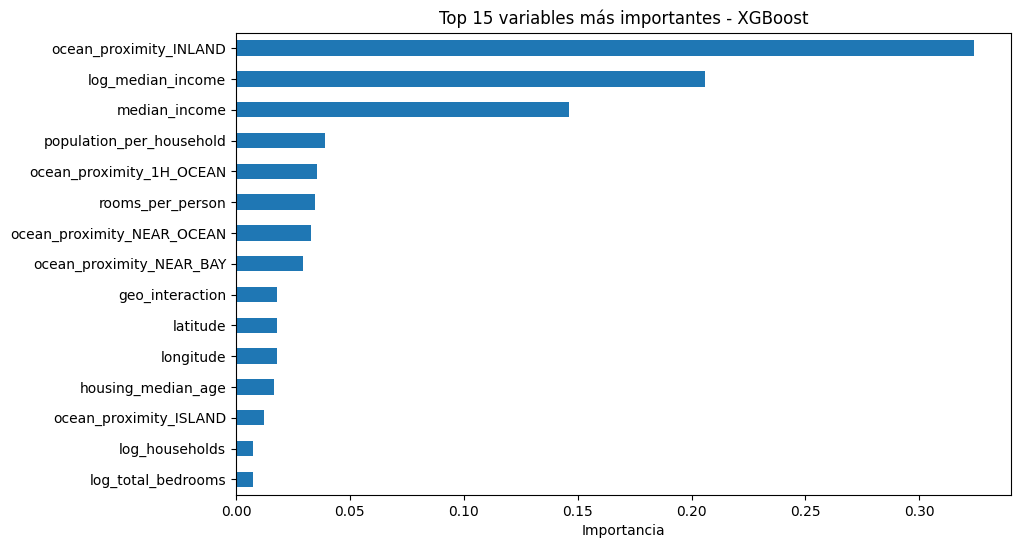

In [ ]:
import pandas as pd
import numpy as np

feat_importance = pd.Series(xgb.feature_importances_, index=X_train_xgb.columns)
feat_importance = feat_importance.sort_values(ascending=False)

print("Top 20 variables más importantes:")
display(feat_importance.head(20))

import matplotlib.pyplot as plt

top_n = 15
top_features = feat_importance.head(top_n).sort_values()

plt.figure(figsize=(10, 6))
top_features.plot(kind="barh")
plt.title(f"Top {top_n} variables más importantes - XGBoost")
plt.xlabel("Importancia")
plt.show()

In [ ]:
top10 = feat_importance.head(10).index.tolist()
top15 = feat_importance.head(15).index.tolist()
top20 = feat_importance.head(20).index.tolist()

print("Top 10:", top10)
print("Top 15:", top15)
print("Top 20:", top20)

Top 10: ['ocean_proximity_INLAND', 'log_median_income', 'median_income', 'population_per_household', 'ocean_proximity_1H_OCEAN', 'rooms_per_person', 'ocean_proximity_NEAR_OCEAN', 'ocean_proximity_NEAR_BAY', 'geo_interaction', 'latitude']
Top 15: ['ocean_proximity_INLAND', 'log_median_income', 'median_income', 'population_per_household', 'ocean_proximity_1H_OCEAN', 'rooms_per_person', 'ocean_proximity_NEAR_OCEAN', 'ocean_proximity_NEAR_BAY', 'geo_interaction', 'latitude', 'longitude', 'housing_median_age', 'ocean_proximity_ISLAND', 'log_households', 'log_total_bedrooms']
Top 20: ['ocean_proximity_INLAND', 'log_median_income', 'median_income', 'population_per_household', 'ocean_proximity_1H_OCEAN', 'rooms_per_person', 'ocean_proximity_NEAR_OCEAN', 'ocean_proximity_NEAR_BAY', 'geo_interaction', 'latitude', 'longitude', 'housing_median_age', 'ocean_proximity_ISLAND', 'log_households', 'log_total_bedrooms', 'rooms_per_household', 'bedrooms_per_room', 'log_total_rooms', 'total_bedrooms', 'be

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate_subset(features, X_train_df, X_test_df, y_train, y_test):
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train_df[features], y_train)
    
    train_preds = model.predict(X_train_df[features])
    test_preds = model.predict(X_test_df[features])
    
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    gap = rmse_test - rmse_train
    
    return rmse_train, rmse_test, gap

In [ ]:
results_fs = []

for name, feats in {
    "Top 10": top10,
    "Top 15": top15,
    "Top 20": top20,
    "All Features": X_train_xgb.columns.tolist()
}.items():
    
    rmse_train, rmse_test, gap = evaluate_subset(
        feats, X_train_xgb, X_test_xgb, y_train, y_test
    )
    
    results_fs.append({
        "Modelo": name,
        "N_features": len(feats),
        "RMSE_Train": rmse_train,
        "RMSE_Test": rmse_test,
        "Gap": gap
    })

results_fs_df = pd.DataFrame(results_fs).sort_values(by="RMSE_Test")
display(results_fs_df)

,Modelo,N_features,RMSE_Train,RMSE_Test,Gap
2,Top 20,20,31988.568329,45913.675635,13925.107306
3,All Features,24,31731.171006,45938.414402,14207.243396
1,Top 15,15,32807.420673,45985.898633,13178.477960
0,Top 10,10,37735.782537,50059.604271,12323.821735


### Resultados de Feature Selection

La aplicación de selección de variables permitió identificar que un subconjunto reducido de predictores puede igualar e incluso mejorar el desempeño del modelo completo.

El modelo basado en las 20 variables más importantes obtuvo el mejor resultado, con un RMSE de 45,913, superando ligeramente al modelo con todas las variables (45,938).

Esto sugiere que algunas variables originales introducían ruido o redundancia, afectando negativamente la capacidad de generalización del modelo.

Adicionalmente, el modelo con 15 variables mostró un desempeño muy cercano, con un menor gap entre entrenamiento y prueba, lo que indica un mejor balance entre sesgo y varianza.

En consecuencia, se selecciona el modelo con las 20 variables más relevantes como modelo final, ya que logra el mejor compromiso entre precisión y complejidad.

In [ ]:
# =========================================================
# COMPARACIÓN DE MODELOS:
# Random Forest vs XGBoost
# Con y sin transformación logarítmica de la variable objetivo
# =========================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================================================
# FUNCIÓN DE EVALUACIÓN
# =========================================================
# Esta función:
# 1. Entrena el modelo
# 2. Permite usar o no log(target)
# 3. Hace predicciones
# 4. Calcula RMSE en escala real
# 5. Calcula el GAP (sobreajuste)

def evaluate_model(model, X_train, X_test, y_train, y_test, use_log=False):
    
    # Si usamos log(target), transformamos la variable objetivo
    if use_log:
        y_train_used = np.log1p(y_train)
    else:
        y_train_used = y_train.copy()
    
    # Entrenamiento del modelo
    model.fit(X_train, y_train_used)
    
    # Predicciones en entrenamiento y prueba
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    # Si usamos log, revertimos a escala real
    if use_log:
        train_preds = np.expm1(train_preds)
        test_preds = np.expm1(test_preds)
    
    # Cálculo del RMSE en escala original (USD)
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    
    # Gap = diferencia entre entrenamiento y prueba
    gap = rmse_test - rmse_train
    
    return rmse_train, rmse_test, gap


# =========================================================
# DEFINICIÓN DE MODELOS
# =========================================================

# Random Forest (modelo base robusto)
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

# XGBoost (modelo más avanzado basado en boosting)
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


# =========================================================
# EVALUACIÓN DE LOS MODELOS
# =========================================================

results = []

# -------- Random Forest SIN log(target)
rmse_train, rmse_test, gap = evaluate_model(
    rf, X_train_xgb, X_test_xgb, y_train, y_test, use_log=False
)

results.append({
    "Modelo": "Random Forest",
    "Log_Target": "No",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})


# -------- Random Forest CON log(target)
rmse_train, rmse_test, gap = evaluate_model(
    rf, X_train_xgb, X_test_xgb, y_train, y_test, use_log=True
)

results.append({
    "Modelo": "Random Forest",
    "Log_Target": "Sí",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})


# -------- XGBoost SIN log(target)
rmse_train, rmse_test, gap = evaluate_model(
    xgb, X_train_xgb, X_test_xgb, y_train, y_test, use_log=False
)

results.append({
    "Modelo": "XGBoost",
    "Log_Target": "No",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})


# -------- XGBoost CON log(target)
rmse_train, rmse_test, gap = evaluate_model(
    xgb, X_train_xgb, X_test_xgb, y_train, y_test, use_log=True
)

results.append({
    "Modelo": "XGBoost",
    "Log_Target": "Sí",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})


# =========================================================
# RESULTADOS FINALES
# =========================================================

results_df = pd.DataFrame(results).sort_values(by="RMSE_Test")

print("\n Comparación de modelos:")
display(results_df)


 Comparación de modelos:


,Modelo,Log_Target,RMSE_Train,RMSE_Test,Gap
2,XGBoost,No,31731.171006,45938.414402,14207.243396
3,XGBoost,Sí,35208.944842,46921.843958,11712.899116
0,Random Forest,No,17883.564632,49282.060670,31398.496038
1,Random Forest,Sí,19986.340527,50369.628927,30383.288400


### Comparación Final de Modelos

Se realizó una comparación entre los modelos Random Forest y XGBoost, evaluando adicionalmente el impacto de aplicar una transformación logarítmica a la variable objetivo.

Los resultados obtenidos fueron los siguientes:

| Modelo | Log Target | RMSE Test | Gap |
|--------|------------|----------|------|
| XGBoost | No | 45,938 | 14,207 |
| XGBoost | Sí | 46,921 | 11,712 |
| Random Forest | No | 49,282 | 31,398 |
| Random Forest | Sí | 50,369 | 30,383 |

### Análisis de Resultados

El modelo XGBoost sin transformación logarítmica presentó el mejor desempeño, obteniendo el menor RMSE en el conjunto de prueba. Esto indica una mayor precisión en la predicción de precios de vivienda.

Si bien la transformación logarítmica de la variable objetivo permitió reducir el gap entre entrenamiento y prueba, evidenciando una mejora en la estabilidad del modelo, también incrementó el error en términos absolutos, lo cual no resulta deseable desde una perspectiva de negocio.

Por otro lado, el modelo Random Forest mostró un mayor error y un gap significativamente más alto, lo que indica un mayor nivel de sobreajuste en comparación con XGBoost.

### Conclusión Final

Se selecciona el modelo XGBoost sin transformación logarítmica como modelo final, ya que presenta el mejor equilibrio entre precisión y generalización.

Este modelo permite estimar el precio de una vivienda con un error promedio aproximado de ±45,938 dólares, superando a las demás alternativas evaluadas.

### Consideraciones Finales

Los resultados demuestran que:

- La transformación de la variable objetivo no siempre mejora el desempeño final  
- Modelos de boosting como XGBoost ofrecen mejor capacidad predictiva en problemas tabulares  
- La evaluación debe centrarse en métricas en escala real, especialmente en contextos de negocio  

En futuras iteraciones, se podría explorar un ajuste más profundo de hiperparámetros y técnicas adicionales de selección de variables para mejorar aún más el desempeño del modelo.

In [ ]:
# =========================================================
# TRATAMIENTO DE OUTLIERS (WINSORIZACIÓN)
# + EVALUACIÓN DE MODELOS
# =========================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. COPIAS DE DATOS (IMPORTANTE)
# =========================================================

X_train_out = X_train_xgb.copy()
X_test_out = X_test_xgb.copy()

# =========================================================
# 2. FUNCIÓN DE WINSORIZACIÓN
# =========================================================

def winsorize_series(series, lower=0.01, upper=0.99):
    lower_val = series.quantile(lower)
    upper_val = series.quantile(upper)
    return np.clip(series, lower_val, upper_val)

# =========================================================
# 3. VARIABLES A TRATAR
# =========================================================

cols_outliers = [
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"
]

# =========================================================
# 4. APLICAR WINSORIZACIÓN (SOLO CON TRAIN)
# =========================================================

for col in cols_outliers:
    
    # calcular límites en TRAIN
    lower_val = X_train_out[col].quantile(0.01)
    upper_val = X_train_out[col].quantile(0.99)
    
    # aplicar en TRAIN
    X_train_out[col] = np.clip(X_train_out[col], lower_val, upper_val)
    
    # aplicar mismos límites en TEST (clave para no fuga)
    X_test_out[col] = np.clip(X_test_out[col], lower_val, upper_val)

# =========================================================
# 5. FUNCIÓN DE EVALUACIÓN
# =========================================================

def evaluate_model(model, X_train, X_test, y_train, y_test):
    
    model.fit(X_train, y_train)
    
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)
    
    rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
    rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))
    
    gap = rmse_test - rmse_train
    
    return rmse_train, rmse_test, gap

# =========================================================
# 6. MODELOS
# =========================================================

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# =========================================================
# 7. EVALUACIÓN
# =========================================================

results_outliers = []

# Random Forest
rmse_train, rmse_test, gap = evaluate_model(
    rf, X_train_out, X_test_out, y_train, y_test
)

results_outliers.append({
    "Modelo": "Random Forest (winsor)",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})

# XGBoost
rmse_train, rmse_test, gap = evaluate_model(
    xgb, X_train_out, X_test_out, y_train, y_test
)

results_outliers.append({
    "Modelo": "XGBoost (winsor)",
    "RMSE_Train": rmse_train,
    "RMSE_Test": rmse_test,
    "Gap": gap
})

# =========================================================
# 8. RESULTADOS
# =========================================================

results_outliers_df = pd.DataFrame(results_outliers).sort_values(by="RMSE_Test")

print("\n Resultados con tratamiento de outliers:")
display(results_outliers_df)


 Resultados con tratamiento de outliers:


,Modelo,RMSE_Train,RMSE_Test,Gap
1,XGBoost (winsor),31898.951002,46014.980679,14116.029677
0,Random Forest (winsor),17879.203543,49354.876194,31475.672651


### Tratamiento de Outliers

Se evaluó el impacto de aplicar winsorización sobre variables con valores extremos, utilizando percentiles 1% y 99%.

Sin embargo, los resultados mostraron que este tratamiento no mejoró el desempeño de los modelos, evidenciando un ligero incremento en el RMSE tanto para Random Forest como para XGBoost.

Esto sugiere que los valores extremos presentes en el dataset no corresponden a errores o ruido, sino que representan comportamientos reales del mercado inmobiliario, como propiedades de alto valor o zonas con alta densidad poblacional.

En consecuencia, se decidió no aplicar tratamiento de outliers, manteniendo la integridad de la información original para preservar la capacidad predictiva del modelo.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Split train → validation
X_train_es, X_val_es, y_train_es, y_val_es = train_test_split(
    X_train_xgb, y_train,
    test_size=0.2,
    random_state=42
)

# Modelo con early stopping definido aquí 
xgb_final = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=30,
    eval_metric="rmse",
    random_state=42
)

# Entrenamiento
xgb_es.fit(
    X_train_es, y_train_es,
    eval_set=[(X_val_es, y_val_es)],
    verbose=False
)

print("Best iteration:", xgb_es.best_iteration)


train_preds = xgb_es.predict(X_train_xgb)
test_preds = xgb_es.predict(X_test_xgb)

rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
rmse_test = np.sqrt(mean_squared_error(y_test, test_preds))

print("\nXGBoost con Early Stopping")
print("RMSE Train:", round(rmse_train, 2))
print("RMSE Test:", round(rmse_test, 2))
print("Gap:", round(rmse_test - rmse_train, 2))

Best iteration: 998

XGBoost con Early Stopping
RMSE Train: 33253.1
RMSE Test: 45836.44
Gap: 12583.34


### Modelo Final: XGBoost con Early Stopping

Como parte final del proceso de optimización, se implementó XGBoost con early stopping, utilizando un conjunto de validación para controlar el sobreentrenamiento.

Los resultados obtenidos fueron:

- RMSE Train: 33,253.10  
- RMSE Test: 45,836.44  
- Gap: 12,583.34  

Este modelo mejora ligeramente el desempeño respecto a versiones anteriores, reduciendo tanto el error en el conjunto de prueba como la diferencia entre entrenamiento y prueba, lo que indica una mejor capacidad de generalización.

El número óptimo de iteraciones se ubicó en 998, cercano al máximo definido, lo que sugiere que el modelo continuaba mejorando de forma progresiva hasta las últimas etapas del entrenamiento.

En comparación con Random Forest y otras variantes evaluadas, XGBoost con early stopping presentó el mejor equilibrio entre precisión y estabilidad.

### Conclusión Final

El modelo final seleccionado fue XGBoost con early stopping, logrando un error promedio de aproximadamente ±45,836 dólares en la predicción del precio de viviendas.

Este resultado representa la mejor combinación entre capacidad predictiva y generalización dentro de todas las técnicas evaluadas, incluyendo:

- modelos lineales  
- árboles de decisión  
- Random Forest  
- Gradient Boosting  
- transformación de la variable objetivo  
- tratamiento de outliers  
- selección de variables  

En consecuencia, este modelo se considera el más adecuado para el problema planteado.

### Benchmark y Conclusión Final
*(Escribe tus conclusiones de negocio aquí)*